# Taller 6: Morfología matemática

## Cargue y visualice objects.png.

In [1]:
PATH = './imagenes/'

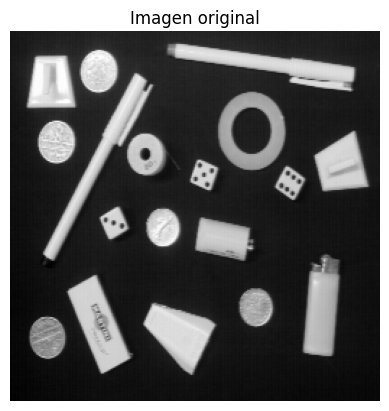

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

imagen = cv2.imread(PATH + 'OBJECTS.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen original')
plt.axis('off')
plt.show()

## Umbralice esta imagen para separar los objetos del fondo (umbral=70).

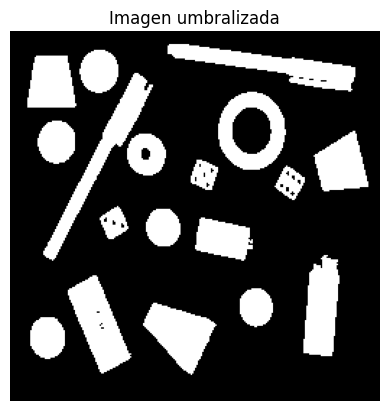

In [5]:
umbral = 70

_, imagen_umbralizada = cv2.threshold(imagen, umbral, 255, cv2.THRESH_BINARY)
plt.imshow(imagen_umbralizada, cmap='gray')
plt.title('Imagen umbralizada')
plt.axis('off')
plt.show()

## Calcule la imagen de distancia. Puede efectuar una expansión del contraste sobre la imagen de distancia para visualizar mejor el resultado. Ajuste el Window/Level.

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

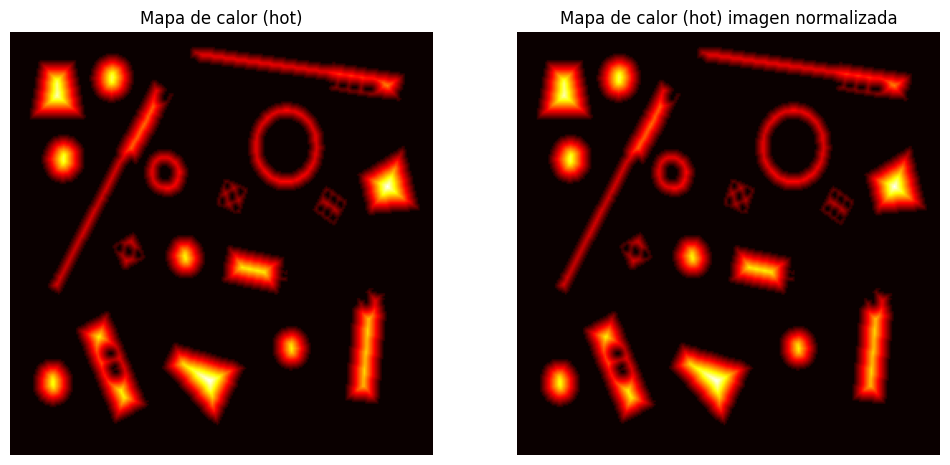

In [9]:
from scipy.ndimage import distance_transform_edt

edm = distance_transform_edt(imagen_umbralizada)

edm_normalizada = ((edm - edm.min()) / (edm.max() - edm.min()) * 255).astype(np.uint8)

# Visualizar con diferentes mapas de color para mejor visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 10))

axes[0].imshow(edm, cmap='hot')
axes[0].set_title('Mapa de calor (hot)')
axes[0].axis('off')

axes[1].imshow(edm_normalizada, cmap='hot')
axes[1].set_title('Mapa de calor (hot) imagen normalizada')
axes[1].axis('off')


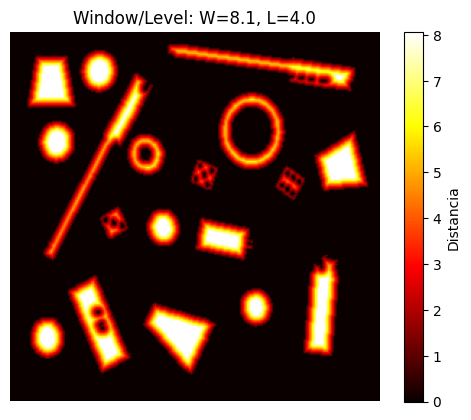

In [10]:
# Ajuste de Window/Level manual
# Window = rango de valores a mostrar
# Level = centro del rango

# Ejemplo: mostrar solo valores entre 0 y la mitad del máximo
window = edm.max() / 2
level = window / 2

vmin = level - window / 2
vmax = level + window / 2

plt.imshow(edm, cmap='hot', vmin=vmin, vmax=vmax)
plt.title(f'Window/Level: W={window:.1f}, L={level:.1f}')
plt.colorbar(label='Distancia')
plt.axis('off')
plt.show()

Para apoyar la interpretación de la imagen:

- Window define el rango de valores que se visualizan, y Level es el centro de ese rango. Permiten ajustar el contraste enfocándose en un subconjunto específico de intensidades.
- Cada píxel tiene un valor igual a su distancia al borde más cercano del objeto. Valores altos (brillantes) = centro del objeto; valores bajos (oscuros) = cerca del borde.

## Calcule ahora el negativo de la imagen umbralizada del punto 3. Ahora realice el cálculo de la distancia euclidiana. Utilizando la imagen resultante, determine la distancia mínima entre los dos lápices. Utilice máscaras y operaciones sobre pixeles para determinar el valor del pixel en el mapa de distancias a medio camino entre la distancia mínima de los dos lápices.

Calculamos y visualizamos el negativo de la imagen umbralizada

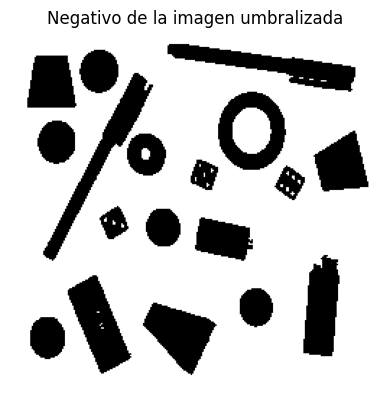

In [12]:
imagen_negativo = cv2.bitwise_not(imagen_umbralizada)

plt.imshow(imagen_negativo, cmap='gray')
plt.title('Negativo de la imagen umbralizada')
plt.axis('off')
plt.show()

Calculamos la distancia euclidiana sobre el negativo.

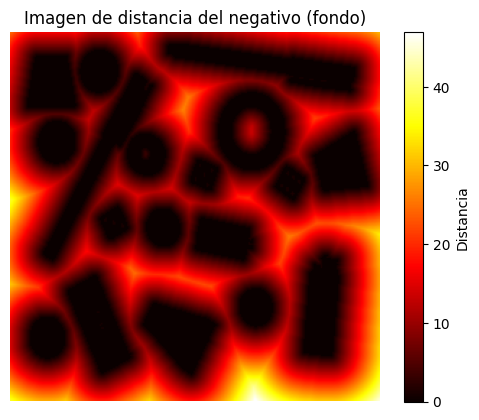

Distancia máxima en el fondo: 46.96 píxeles


In [13]:
edm_negativo = distance_transform_edt(imagen_negativo)

# Visualizar
plt.imshow(edm_negativo, cmap='hot')
plt.title('Imagen de distancia del negativo (fondo)')
plt.colorbar(label='Distancia')
plt.axis('off')
plt.show()

print(f"Distancia máxima en el fondo: {edm_negativo.max():.2f} píxeles")

Cuando se calcula la transformada de distancia en el fondo (negativo), cada píxel blanco tiene un valor igual a su distancia al objeto negro más cercano. El píxel del fondo que está más lejos de cualquier objeto (valor máximo) es el que está exactamente a medio camino entre los dos objetos más cercanos.

Número de objetos detectados: 18


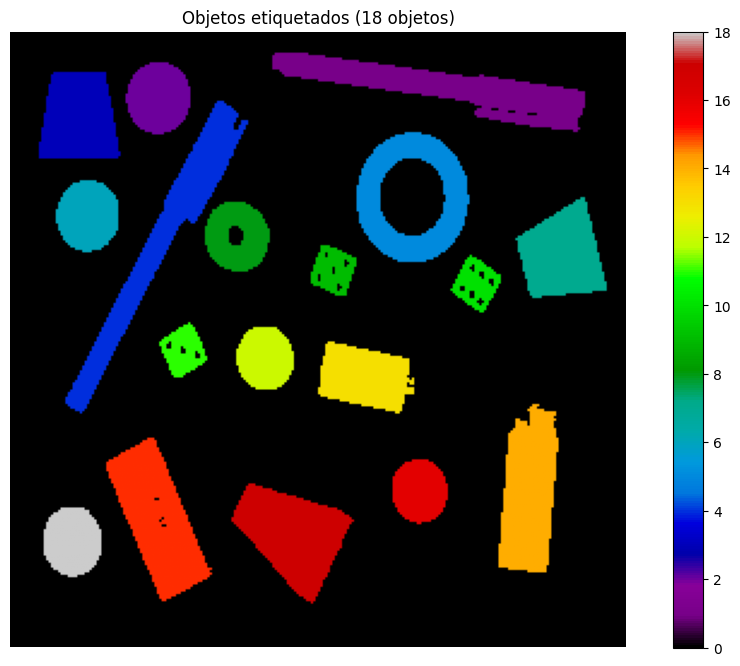

In [16]:
# 1. Etiquetar todos los objetos
from skimage.measure import label, regionprops

objetos_etiquetados = label(imagen_umbralizada, connectivity=2)
num_objetos = objetos_etiquetados.max()

print(f"Número de objetos detectados: {num_objetos}")

# Visualizar objetos etiquetados
plt.figure(figsize=(12, 8))
plt.imshow(objetos_etiquetados, cmap='nipy_spectral')
plt.title(f'Objetos etiquetados ({num_objetos} objetos)')
plt.colorbar()
plt.axis('off')
plt.show()

In [17]:
# 2. Analizar propiedades para identificar lápices (objetos alargados)
regions = regionprops(objetos_etiquetados)

print("Propiedades de cada objeto:")
print("ID | Área | Excentricidad | Largo/Ancho")
print("-" * 50)

lapices_candidatos = []
for region in regions:
    # Excentricidad cercana a 1 = muy alargado (lápiz)
    # Área grande
    eccentricity = region.eccentricity
    area = region.area
    
    print(f"{region.label:2d} | {area:5.0f} | {eccentricity:.3f} | {region.major_axis_length/region.minor_axis_length:.2f}")
    
    # Criterio: objetos muy alargados (excentricidad > 0.9) y área considerable
    if eccentricity > 0.9 and area > 1000:
        lapices_candidatos.append(region.label)

print(f"\nLápices candidatos (muy alargados y grandes): {lapices_candidatos}")

Propiedades de cada objeto:
ID | Área | Excentricidad | Largo/Ancho
--------------------------------------------------
 1 |  1639 | 0.994 | 9.15
 2 |   636 | 0.454 | 1.12
 3 |  1027 | 0.573 | 1.22
 4 |  1618 | 0.996 | 10.81
 5 |  1305 | 0.502 | 1.16
 6 |   618 | 0.485 | 1.14
 7 |  1058 | 0.447 | 1.12
 8 |   581 | 0.422 | 1.10
 9 |   266 | 0.434 | 1.11
10 |   266 | 0.478 | 1.14
11 |   271 | 0.562 | 1.21
12 |   506 | 0.450 | 1.12
13 |   844 | 0.786 | 1.62
14 |  1330 | 0.950 | 3.21
15 |  1475 | 0.928 | 2.68
16 |   492 | 0.492 | 1.15
17 |  1366 | 0.713 | 1.43
18 |   567 | 0.543 | 1.19

Lápices candidatos (muy alargados y grandes): [1, 4, 14, 15]


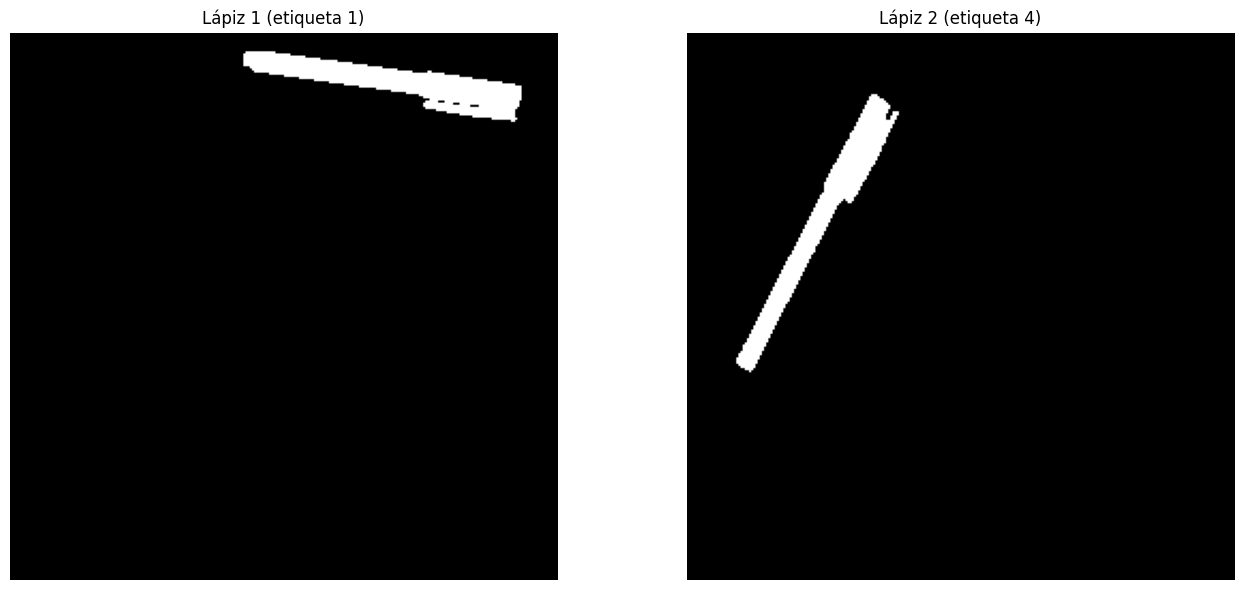

In [18]:
# 3. Si encontramos exactamente 2 lápices, crear máscaras individuales
if len(lapices_candidatos) >= 2:
    lapiz1_label = lapices_candidatos[0]
    lapiz2_label = lapices_candidatos[1]
    
    # Máscaras individuales
    mascara_lapiz1 = (objetos_etiquetados == lapiz1_label).astype(np.uint8) * 255
    mascara_lapiz2 = (objetos_etiquetados == lapiz2_label).astype(np.uint8) * 255
    
    # Visualizar
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(mascara_lapiz1, cmap='gray')
    axes[0].set_title(f'Lápiz 1 (etiqueta {lapiz1_label})')
    axes[0].axis('off')
    
    axes[1].imshow(mascara_lapiz2, cmap='gray')
    axes[1].set_title(f'Lápiz 2 (etiqueta {lapiz2_label})')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Ajustar criterios de selección")

In [21]:
# Método correcto: distancia mínima entre bordes
# Calcular distancia desde lápiz 1
dist_desde_lapiz1 = distance_transform_edt(cv2.bitwise_not(mascara_lapiz1))

# Encontrar la distancia mínima en los píxeles del lápiz 2
distancias_en_lapiz2 = dist_desde_lapiz1[mascara_lapiz2 > 0]
distancia_minima = distancias_en_lapiz2.min()

# Encontrar el punto del lápiz 2 más cercano al lápiz 1
punto_en_lapiz2 = np.where((dist_desde_lapiz1 == distancia_minima) & (mascara_lapiz2 > 0))
y2, x2 = punto_en_lapiz2[0][0], punto_en_lapiz2[1][0]

# Encontrar el punto correspondiente en lápiz 1
dist_desde_lapiz2 = distance_transform_edt(cv2.bitwise_not(mascara_lapiz2))
punto_en_lapiz1 = np.where((dist_desde_lapiz2 == distancia_minima) & (mascara_lapiz1 > 0))

if len(punto_en_lapiz1[0]) > 0:
    y1, x1 = punto_en_lapiz1[0][0], punto_en_lapiz1[1][0]
else:
    # Aproximar usando la dirección desde punto en lápiz 2
    y1, x1 = y2, x2

# Punto medio entre los dos puntos más cercanos
y_medio = (y1 + y2) // 2
x_medio = (x1 + x2) // 2

print(f"Distancia mínima entre lápices: {distancia_minima:.2f} píxeles")
print(f"Punto más cercano en lápiz 2: ({y2}, {x2})")
print(f"Punto más cercano en lápiz 1: ({y1}, {x1})")
print(f"Punto medio: ({y_medio}, {x_medio})")
print(f"Valor en mapa distancia fondo: {edm_negativo[y_medio, x_medio]:.2f}")

Distancia mínima entre lápices: 24.04 píxeles
Punto más cercano en lápiz 2: (32, 92)
Punto más cercano en lápiz 1: (15, 109)
Punto medio: (23, 100)
Valor en mapa distancia fondo: 12.04


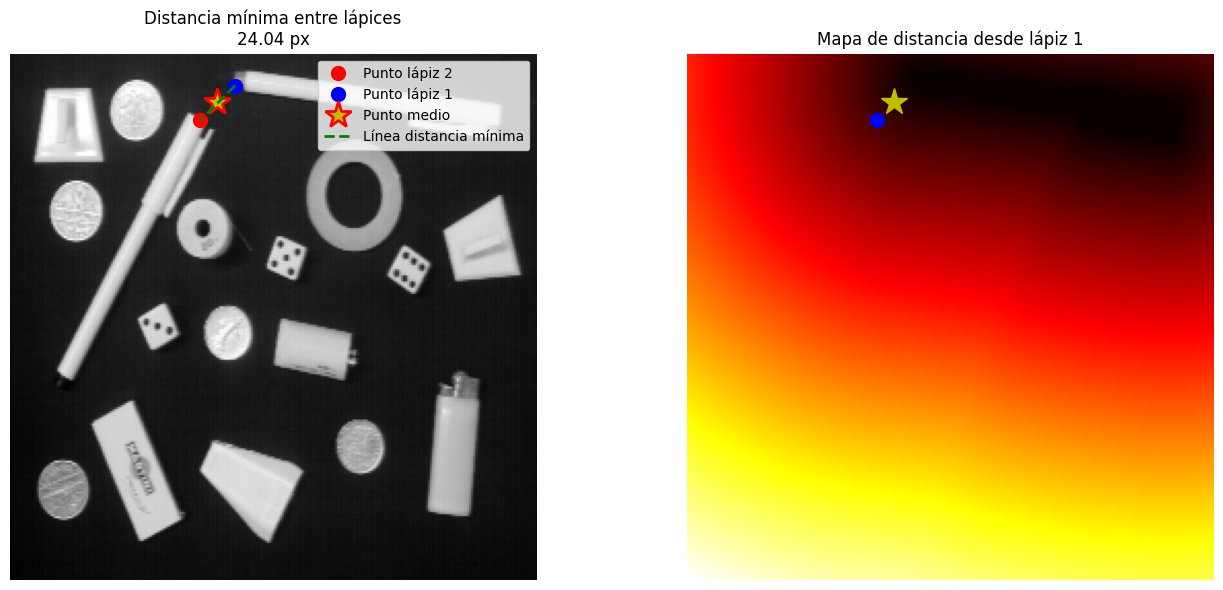

In [23]:
# Visualización correcta
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(imagen, cmap='gray')
axes[0].plot(x2, y2, 'ro', markersize=10, label='Punto lápiz 2')
axes[0].plot(x1, y1, 'bo', markersize=10, label='Punto lápiz 1')
axes[0].plot(x_medio, y_medio, 'y*', markersize=20, markeredgecolor='red', markeredgewidth=2, label='Punto medio')
axes[0].plot([x1, x2], [y1, y2], 'g--', linewidth=2, label='Línea distancia mínima')
axes[0].set_title(f'Distancia mínima entre lápices\n{distancia_minima:.2f} px')
axes[0].legend()
axes[0].axis('off')

axes[1].imshow(dist_desde_lapiz1, cmap='hot')
axes[1].plot(x2, y2, 'bo', markersize=10)
axes[1].plot(x_medio, y_medio, 'y*', markersize=20)
axes[1].set_title('Mapa de distancia desde lápiz 1')
axes[1].axis('off')

plt.tight_layout()
plt.show()